In [43]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [7]:
PRIMARY  = "INTC"
DATE     = "2012-06-21"
LEVELS   = 5
K        = 5
MARKET_OPEN_S  = 34200   # 09:30 in seconds since midnight
MARKET_CLOSE_S = 57600   # 16:00

DATA_DIR     = Path("data")
stock_folder = DATA_DIR / f"LOBSTER_SampleFile_{PRIMARY}_{DATE}_5"
msg_path = stock_folder / f"{PRIMARY}_{DATE}_34200000_57600000_message_{LEVELS}.csv"
ob_path  = stock_folder / f"{PRIMARY}_{DATE}_34200000_57600000_orderbook_{LEVELS}.csv"

msg = pd.read_csv(msg_path, header=None)
ob  = pd.read_csv(ob_path, header=None)

msg.columns = ["time", "event_type", "order_id", "size", "price", "direction"]

ob_cols = []
for lvl in range(1, 6):
    ob_cols += [f"ask_price_{lvl}", f"ask_size_{lvl}",
                f"bid_price_{lvl}", f"bid_size_{lvl}"]
ob.columns = ob_cols

df = pd.concat([msg, ob], axis=1)

In [9]:
df

,time,event_type,order_id,size,price,direction,ask_price_1,ask_size_1,bid_price_1,bid_size_1,...,bid_price_3,bid_size_3,ask_price_4,ask_size_4,bid_price_4,bid_size_4,ask_price_5,ask_size_5,bid_price_5,bid_size_5
0,34200.005743,4,15835012,34,275200,-1,275200,66,275100,400,...,274900,200,275600,100,274800,661,275700,100,274700,300
1,34200.006241,1,16114545,100,275200,-1,275200,166,275100,400,...,274900,200,275600,100,274800,661,275700,100,274700,300
2,34200.006462,1,16114695,100,275500,-1,275200,166,275100,400,...,274900,200,275500,100,274800,661,275600,100,274700,300
3,34200.048864,3,16063194,100,275000,1,275200,166,275100,400,...,274800,661,275500,100,274700,300,275600,100,274600,700
4,34200.048883,3,15833239,100,275100,1,275200,166,275100,300,...,274800,661,275500,100,274700,300,275600,100,274600,700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581025,57599.860444,3,287139444,34600,267200,-1,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581026,57599.860635,1,287166269,16600,267000,1,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581027,57599.870108,3,287016725,600,267400,-1,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581028,57599.939645,1,287173095,100,267200,-1,267200,88204,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174


In [8]:
#récupérer les trades 

trades = df[df["event_type"].isin([4, 5])].copy()
trades = trades[["time", "price", "size", "direction"]].reset_index(drop=True)

In [10]:
#estimer tick size 

#c'est le plus petit écart de prix strictement positif
price_diffs = trades["price"].diff().abs()
alpha = price_diffs[price_diffs > 0].min()

print("Tick alpha =", alpha)

Tick alpha = 50.0


In [12]:
price_diffs = trades["price"].diff().dropna().abs()
price_diffs = price_diffs[price_diffs > 0]

print(price_diffs.value_counts().head(10))

price
50.0     1653
100.0    1061
200.0      54
150.0      21
300.0       1
Name: count, dtype: int64


tous les autres tick size observés sont des multiples de 50 donc on considère tick size=50

In [ ]:
#garder instants ou prix change

pchg = trades.loc[trades["price"].shift().ne(trades["price"])].copy()
pchg["dP"] = pchg["price"].diff() #deltaP 
pchg["sign_dP"] = np.sign(pchg["dP"]) #direction du mouvement 
pchg["abs_ticks"] = pchg["dP"].abs() / alpha #taille du mouvement en nombre de ticks

pchg = pchg.reset_index(drop=True)

In [25]:
def estimate_eta_full(pchg, alpha):
    tmp = pchg.copy()

    # on garde seulement les vraies variations de prix
    tmp = tmp.loc[tmp["dP"].notna()].copy()

    # taille du saut en ticks
    tmp["k"] = (tmp["dP"].abs() / alpha).round().astype(int)

    # signe du saut
    tmp["sign"] = np.sign(tmp["dP"]).astype(int)

    # variables décalées pour former les paires successives
    tmp["k_prev"] = tmp["k"].shift()
    tmp["sign_prev"] = tmp["sign"].shift()

    # on enlève la première ligne des paires
    tmp = tmp.loc[tmp["k_prev"].notna() & tmp["sign_prev"].notna()].copy()

    # alternation = changement de signe
    is_alt = tmp["sign"] == -tmp["sign_prev"]

    # continuation = même signe
    is_cont = tmp["sign"] == tmp["sign_prev"]

    # comptes agrégés
    Na = is_alt.sum()
    Nc = is_cont.sum()

    eta_hat = 0.5 * Nc / Na if Na > 0 else np.nan

    return eta_hat, Na, Nc, tmp

In [ ]:
#1) estimer eta journalier

eta_hat, Na, Nc, eta_df = estimate_eta_full(pchg, alpha)

print("eta_hat =", eta_hat)
print("Na =", Na)
print("Nc =", Nc)

eta_hat = 0.3212603062426384
Na = 1698
Nc = 1091


In [ ]:
#2) X chapeau reconstruit sur tt la journée

pchg["sign_dP"] = np.sign(pchg["dP"]).fillna(0)

pchg["x_hat"] = (
    pchg["price"]
    - alpha * (0.5 - eta_hat) * pchg["sign_dP"]
)

pchg.loc[pchg.index[0], "x_hat"] = pchg.loc[pchg.index[0], "price"]

In [31]:
#calcul de rv

pchg["log_x_hat"] = np.log(pchg["x_hat"])
pchg["dlog_x_hat"] = pchg["log_x_hat"].diff()
pchg["rv_increment"] = pchg["dlog_x_hat"]**2
pchg["rv_cum"] = pchg["rv_increment"].fillna(0).cumsum()

daily_rv = pchg["rv_increment"].sum()
daily_vol = np.sqrt(daily_rv)

print("Daily RV =", daily_rv)
print("Daily intraday vol =", daily_vol)

Daily RV = 0.00018456296521417122
Daily intraday vol = 0.013585395291053229


In [ ]:
#3) RV(t) cumulé = volatilité accumulée depuis le début de la journée

rv_curve = pchg[["time", "rv_cum"]].copy()

#vol locale : c'est RV sur une fênêtre delta t 

#je comprends que : 
# η= sorte de paramètre de nettoyage X = prix corrigé et RV = volatilité mesurée sur le prix corrigé
#pipeline η --> X --> RV

In [36]:
rv_curve

,time,rv_cum
0,34200.005743,0.000000e+00
1,34200.441108,1.095295e-07
2,34200.649465,5.475023e-07
3,34200.783992,6.365263e-07
4,34200.912227,7.255503e-07
...,...,...
2786,57598.214818,1.844846e-04
2787,57598.221989,1.844990e-04
2788,57598.401422,1.845135e-04
2789,57598.408973,1.845279e-04


In [37]:
#4)RV par bucket 

BUCKET_SEC = 300  # 5 minutes

pchg_5m = pchg.copy()

# index de bucket depuis l'ouverture
pchg_5m["bucket_5m"] = ((pchg_5m["time"] - MARKET_OPEN_S) // BUCKET_SEC).astype(int)

rv_5m = (
    pchg_5m.groupby("bucket_5m", as_index=False)
    .agg(
        t_start=("time", "min"),
        t_end=("time", "max"),
        n_price_changes=("rv_increment", "size"),
        rv_5m=("rv_increment", "sum")
    )
)

rv_5m["vol_5m"] = np.sqrt(rv_5m["rv_5m"])

rv_5m.head()

,bucket_5m,t_start,t_end,n_price_changes,rv_5m,vol_5m
0,0,34200.005743,34496.493238,214,0.000029,0.005352
1,1,34500.116712,34793.467227,92,0.000009,0.003023
2,2,34807.133844,35093.044643,41,0.000005,0.002135
3,3,35109.436395,35394.191569,42,0.000004,0.002054
4,4,35431.738914,35699.094640,39,0.000004,0.002015


In [38]:
#mettre l'heure pr chaque bucket

rv_5m["clock_start"] = pd.to_datetime(rv_5m["t_start"], unit="s").dt.strftime("%H:%M:%S")
rv_5m["clock_end"]   = pd.to_datetime(rv_5m["t_end"], unit="s").dt.strftime("%H:%M:%S")

rv_5m.head(10)

,bucket_5m,t_start,t_end,n_price_changes,rv_5m,vol_5m,clock_start,clock_end
0,0,34200.005743,34496.493238,214,2.864533e-05,0.005352,09:30:00,09:34:56
1,1,34500.116712,34793.467227,92,9.137641e-06,0.003023,09:35:00,09:39:53
2,2,34807.133844,35093.044643,41,4.559663e-06,0.002135,09:40:07,09:44:53
3,3,35109.436395,35394.191569,42,4.218505e-06,0.002054,09:45:09,09:49:54
4,4,35431.738914,35699.094640,39,4.059005e-06,0.002015,09:50:31,09:54:59
5,5,35710.970024,35999.276936,25,2.437602e-06,0.001561,09:55:10,09:59:59
6,6,36000.226388,36291.905261,71,6.532969e-06,0.002556,10:00:00,10:04:51
7,7,36303.724449,36591.907537,47,2.021131e-06,0.001422,10:05:03,10:09:51
8,8,36653.093352,36868.030973,21,1.046614e-06,0.001023,10:10:53,10:14:28
9,9,36908.201109,37151.185536,25,9.283835e-07,0.000964,10:15:08,10:19:11


In [39]:
#construire variable carnet 
book = df.copy()

book["spread"] = book["ask_price_1"] - book["bid_price_1"]
book["mid"] = (book["ask_price_1"] + book["bid_price_1"]) / 2

book["imbalance"] = (
    (book["bid_size_1"] - book["ask_size_1"]) /
    (book["bid_size_1"] + book["ask_size_1"])
)

book["depth_top1"] = book["bid_size_1"] + book["ask_size_1"]

book["bucket_5m"] = ((book["time"] - MARKET_OPEN_S) // BUCKET_SEC).astype(int)

book_5m = (
    book.groupby("bucket_5m", as_index=False)
    .agg(
        spread_mean=("spread", "mean"),
        spread_median=("spread", "median"),
        imbalance_mean=("imbalance", "mean"),
        depth_top1_mean=("depth_top1", "mean"),
        mid_mean=("mid", "mean"),
        n_events=("time", "size")
    )
)

book_5m.head()

,bucket_5m,spread_mean,spread_median,imbalance_mean,depth_top1_mean,mid_mean,n_events
0,0,168.470875,200.0,0.273005,3400.759181,275005.720963,25459
1,1,138.454510,100.0,0.267286,17060.459666,274404.144368,15322
2,2,127.821034,100.0,0.168801,10862.718536,273793.288786,8605
3,3,123.165023,100.0,0.006466,14744.784484,273617.234339,10041
4,4,122.387916,100.0,0.058165,15197.254570,273461.598037,10394


In [40]:
#nombre de trades et volume exec
trades_5m = trades.copy()
trades_5m["bucket_5m"] = ((trades_5m["time"] - MARKET_OPEN_S) // BUCKET_SEC).astype(int)

trade_stats_5m = (
    trades_5m.groupby("bucket_5m", as_index=False)
    .agg(
        n_trades=("price", "size"),
        traded_volume=("size", "sum")
    )
)

trade_stats_5m.head()

,bucket_5m,n_trades,traded_volume
0,0,1321,241984
1,1,818,266868
2,2,501,157273
3,3,529,136238
4,4,578,138911


In [41]:
#nbr de price changes par 5min
price_changes_5m = (
    pchg_5m.groupby("bucket_5m", as_index=False)
    .agg(
        n_price_changes=("price", "size")
    )
)

price_changes_5m.head()

,bucket_5m,n_price_changes
0,0,214
1,1,92
2,2,41
3,3,42
4,4,39


In [42]:
analysis_5m = rv_5m.merge(book_5m, on="bucket_5m", how="left")
analysis_5m = analysis_5m.merge(trade_stats_5m, on="bucket_5m", how="left")
analysis_5m = analysis_5m.merge(price_changes_5m, on="bucket_5m", how="left", suffixes=("", "_check"))

analysis_5m.head(10)

,bucket_5m,t_start,t_end,n_price_changes,rv_5m,vol_5m,clock_start,clock_end,spread_mean,spread_median,imbalance_mean,depth_top1_mean,mid_mean,n_events,n_trades,traded_volume,n_price_changes_check
0,0,34200.005743,34496.493238,214,2.864533e-05,0.005352,09:30:00,09:34:56,168.470875,200.0,0.273005,3400.759181,275005.720963,25459,1321,241984,214
1,1,34500.116712,34793.467227,92,9.137641e-06,0.003023,09:35:00,09:39:53,138.454510,100.0,0.267286,17060.459666,274404.144368,15322,818,266868,92
2,2,34807.133844,35093.044643,41,4.559663e-06,0.002135,09:40:07,09:44:53,127.821034,100.0,0.168801,10862.718536,273793.288786,8605,501,157273,41
3,3,35109.436395,35394.191569,42,4.218505e-06,0.002054,09:45:09,09:49:54,123.165023,100.0,0.006466,14744.784484,273617.234339,10041,529,136238,42
4,4,35431.738914,35699.094640,39,4.059005e-06,0.002015,09:50:31,09:54:59,122.387916,100.0,0.058165,15197.254570,273461.598037,10394,578,138911,39
5,5,35710.970024,35999.276936,25,2.437602e-06,0.001561,09:55:10,09:59:59,126.943494,100.0,0.032741,15131.073965,273625.580984,8477,485,144013,25
6,6,36000.226388,36291.905261,71,6.532969e-06,0.002556,10:00:00,10:04:51,130.885332,100.0,0.071911,14963.268278,272806.801699,15305,826,237732,71
7,7,36303.724449,36591.907537,47,2.021131e-06,0.001422,10:05:03,10:09:51,124.235539,100.0,0.064521,20232.015905,272369.615639,10563,440,128878,47
8,8,36653.093352,36868.030973,21,1.046614e-06,0.001023,10:10:53,10:14:28,106.673407,100.0,0.372420,23402.893225,272932.770475,4945,226,56816,21
9,9,36908.201109,37151.185536,25,9.283835e-07,0.000964,10:15:08,10:19:11,117.486424,100.0,0.134172,23247.833980,273351.373157,6445,368,123781,25


In [67]:
#prix et vol avec bucket 5min

rv_5m = (
    pchg_5m.groupby("bucket_5m", as_index=False)
    .agg(
        t_start=("time", "min"),
        t_end=("time", "max"),
        n_price_changes=("rv_increment", "size"),
        rv_5m=("rv_increment", "sum"),
        price_obs=("price", "last"),
        price_eff=("x_hat", "last")
    )
)

rv_5m["vol_5m"] = np.sqrt(rv_5m["rv_5m"])

# temps au milieu du bucket 
rv_5m["t_mid"] = (rv_5m["t_start"] + rv_5m["t_end"]) / 2
rv_5m["datetime"] = pd.to_datetime(rv_5m["t_mid"], unit="s")

# annualisation
MINUTES_PER_YEAR = 252 * 6.5 * 60
annualization_factor_5m = np.sqrt(MINUTES_PER_YEAR / 5)
rv_5m["vol_5m_annualized"] = rv_5m["vol_5m"] * annualization_factor_5m

rv_5m.head()

,bucket_5m,t_start,t_end,n_price_changes,rv_5m,price_obs,price_eff,vol_5m,t_mid,datetime,vol_5m_annualized
0,0,34200.005743,34496.493238,214,0.000029,274900,274908.936985,0.005352,34348.249490,1970-01-01 09:32:28.249490236,0.750368
1,1,34500.116712,34793.467227,92,0.000009,274000,274008.936985,0.003023,34646.791969,1970-01-01 09:37:26.791969028,0.423804
2,2,34807.133844,35093.044643,41,0.000005,273600,273591.063015,0.002135,34950.089243,1970-01-01 09:42:30.089243426,0.299374
3,3,35109.436395,35394.191569,42,0.000004,273600,273608.936985,0.002054,35251.813982,1970-01-01 09:47:31.813981704,0.287956
4,4,35431.738914,35699.094640,39,0.000004,273700,273708.936985,0.002015,35565.416777,1970-01-01 09:52:45.416776810,0.282460


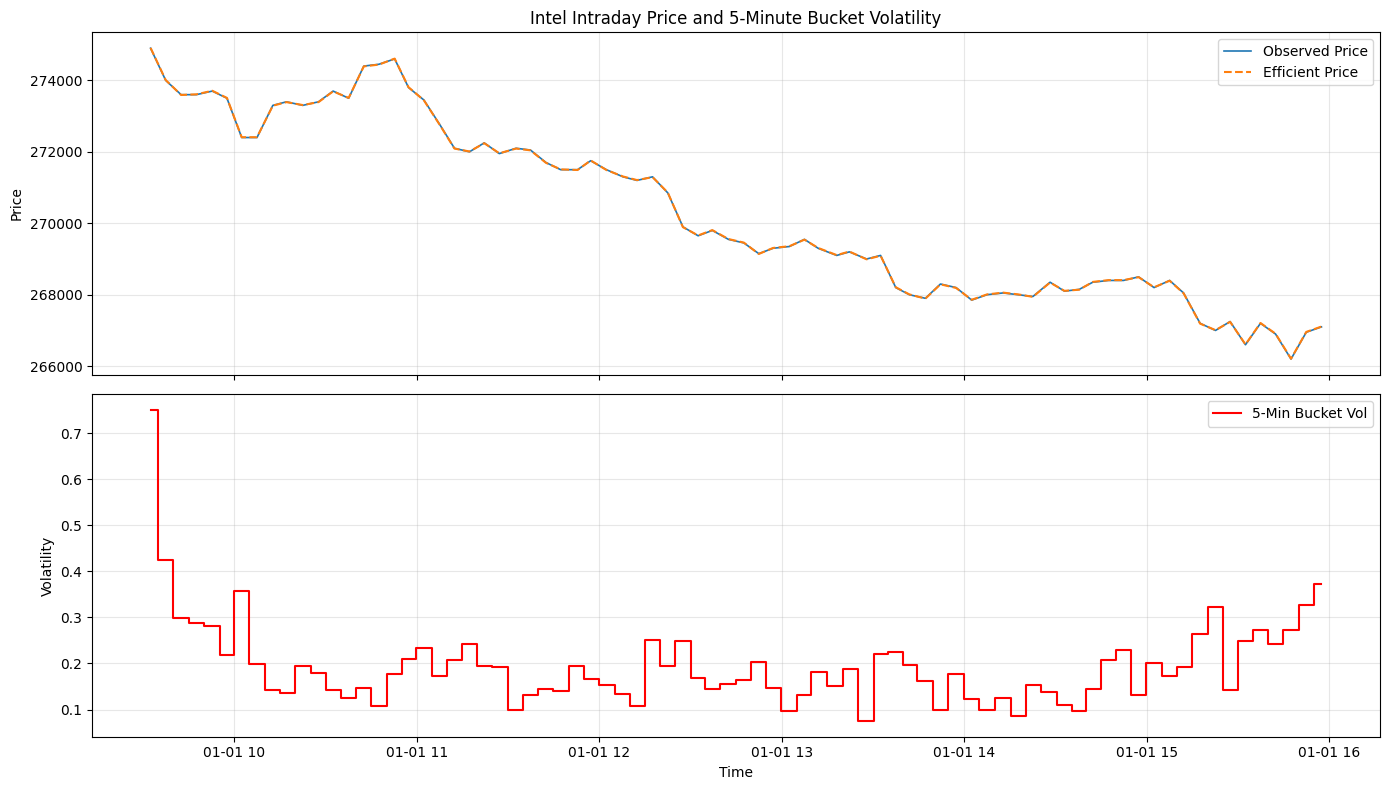

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

#prix
axes[0].plot(rv_5m["datetime"], rv_5m["price_obs"], label="Observed Price", linewidth=1.2)
axes[0].plot(rv_5m["datetime"], rv_5m["price_eff"], "--", label="Efficient Price", linewidth=1.5)
axes[0].set_title("Intel Intraday Price and 5-Minute Bucket Volatility")
axes[0].set_ylabel("Price")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#volatilité locale par bucket 5 min
axes[1].step(
    rv_5m["datetime"],
    rv_5m["vol_5m_annualized"],   
    where="mid",
    color="red",
    label="5-Min Bucket Vol",
    linewidth=1.5
)

axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
#essai comme thib
plot_df = pchg.copy()

# temps en datetime
plot_df["datetime"] = pd.to_datetime(plot_df["time"], unit="s")

plot_df["log_x_hat"] = np.log(plot_df["x_hat"])
plot_df["dlog_x_hat"] = plot_df["log_x_hat"].diff()
plot_df["rv_increment"] = plot_df["dlog_x_hat"]**2

# rolling RV sur 10 minutes = 600 secondes
WINDOW_SEC = 600

times = plot_df["time"].values
rv_inc = plot_df["rv_increment"].fillna(0).values

rolling_rv_10m = np.zeros(len(plot_df))
left = 0

for right in range(len(plot_df)):
    while times[right] - times[left] > WINDOW_SEC:
        left += 1
    rolling_rv_10m[right] = rv_inc[left:right+1].sum()

plot_df["rolling_rv_10m"] = rolling_rv_10m
plot_df["rolling_vol_10m"] = np.sqrt(plot_df["rolling_rv_10m"])

In [49]:
#annualiser pr fenetre de 10 min

MINUTES_PER_YEAR = 252 * 6.5 * 60
annualization_factor = np.sqrt(MINUTES_PER_YEAR / 10)

plot_df["rolling_vol_10m_annualized"] = (
    plot_df["rolling_vol_10m"] * annualization_factor
)


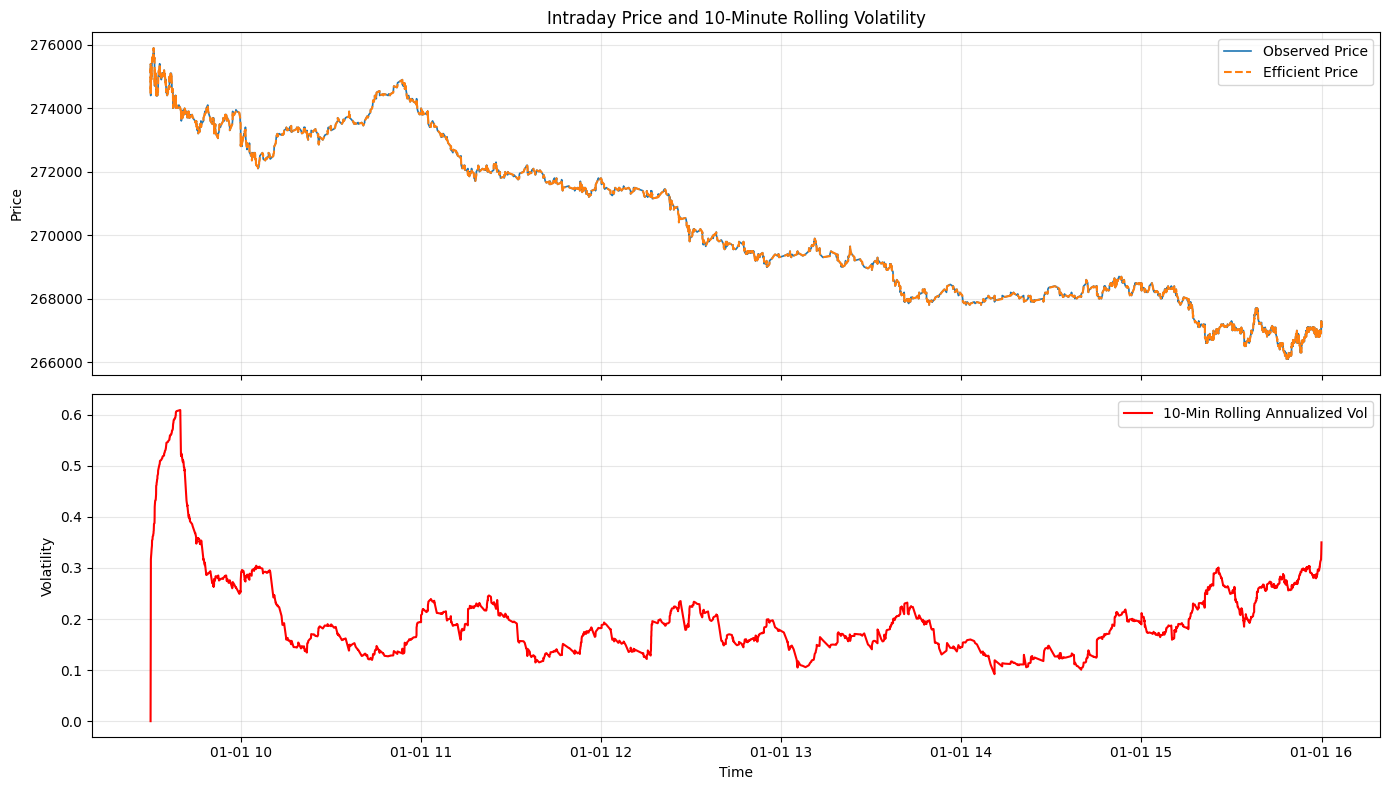

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(plot_df["datetime"], plot_df["price"], label="Observed Price", linewidth=1.2)
axes[0].plot(plot_df["datetime"], plot_df["x_hat"], "--", label="Efficient Price", linewidth=1.5)
axes[0].set_title("Intraday Price and 10-Minute Rolling Volatility")
axes[0].set_ylabel("Price")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    plot_df["datetime"],
    plot_df["rolling_vol_10m_annualized"],
    color="red",
    label="10-Min Rolling Annualized Vol",
    linewidth=1.5
)
axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()